In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name.lower() == "notebooks":
    BASE_DIR = NOTEBOOK_DIR.parent
else:
    BASE_DIR = Path(r"C:\GEO_Breast_Reliability")

DATA_DIR = BASE_DIR / "GSE96058"
PROCESSED_DIR = BASE_DIR / "processed"
RESULTS_DIR = BASE_DIR / "results"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", NOTEBOOK_DIR)
print("Project directory:", BASE_DIR)
print("Validation-data directory:", DATA_DIR)

Notebook directory: C:\GEO_Breast_Reliability
Project directory: C:\GEO_Breast_Reliability
Validation-data directory: C:\GEO_Breast_Reliability\GSE96058


In [2]:
%pip install requests tqdm GEOparse

Note: you may need to restart the kernel to use updated packages.


In [3]:
import requests
from tqdm.auto import tqdm

expression_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/"
    "GSE96nnn/GSE96058/suppl/"
    "GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz"
)

expression_file = (
    DATA_DIR
    / "GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz"
)

temporary_file = DATA_DIR / (
    expression_file.name + ".part"
)

if expression_file.exists():
    print("Expression file already exists:")
    print(expression_file)

else:
    with requests.get(
        expression_url,
        stream=True,
        timeout=120
    ) as response:

        response.raise_for_status()

        total_size = int(
            response.headers.get("content-length", 0)
        )

        with open(temporary_file, "wb") as file_handle:
            with tqdm(
                total=total_size,
                unit="B",
                unit_scale=True,
                desc="Downloading GSE96058"
            ) as progress_bar:

                for chunk in response.iter_content(
                    chunk_size=1024 * 1024
                ):
                    if chunk:
                        file_handle.write(chunk)
                        progress_bar.update(len(chunk))

    temporary_file.replace(expression_file)

    print("\nDownload completed successfully:")
    print(expression_file)

C:\Users\kumia\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download completed successfully:
C:\GEO_Breast_Reliability\GSE96058\GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz


In [4]:
print("File exists:", expression_file.exists())

if expression_file.exists():
    file_size_mb = expression_file.stat().st_size / (1024 ** 2)
    print(f"File size: {file_size_mb:.2f} MB")

File exists: True
File size: 564.27 MB


In [5]:
# Read only five rows to inspect the structure
expression_preview = pd.read_csv(
    expression_file,
    compression="gzip",
    nrows=5,
    low_memory=False
)

print("Preview shape:", expression_preview.shape)
print("\nFirst 15 column names:")
print(expression_preview.columns[:15].tolist())

display(expression_preview.iloc[:, :15])

Preview shape: (5, 3410)

First 15 column names:
['Unnamed: 0', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14']


,Unnamed: 0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14
0,5_8S_rRNA,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
1,5S_rRNA,4.911099,-3.321928,-3.321928,3.656393,4.190104,2.556304,2.590351,5.691788,-3.321928,3.223401,-3.321928,5.265988,4.179053,3.936864
2,6M1-18,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
3,7M1-2,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
4,7SK,-0.539253,-0.576620,-1.651323,0.126633,0.783715,-1.759556,-1.033968,-0.129513,0.494308,0.749841,1.541830,0.049312,1.260500,-0.423132


In [6]:
validation_expression = pd.read_csv(
    expression_file,
    compression="gzip",
    index_col=0,
    dtype=np.float32,
    low_memory=False
)

validation_expression.index.name = "gene_symbol"

print("Validation expression shape:", validation_expression.shape)
print("Number of genes:", validation_expression.shape[0])
print("Number of sample columns:", validation_expression.shape[1])
print(
    "Missing expression values:",
    int(validation_expression.isna().sum().sum())
)

display(validation_expression.iloc[:5, :10])

ValueError: could not convert string to float: '5_8S_rRNA'

In [ ]:
import GEOparse

gse96058 = GEOparse.get_GEO(
    geo="GSE96058",
    destdir=str(DATA_DIR),
    annotate_gpl=False,
    silent=False
)

print("Number of GEO sample records:", len(gse96058.gsms))

In [7]:
import numpy as np
import pandas as pd

validation_chunks = []
non_numeric_records = []

for chunk_number, chunk in enumerate(
    pd.read_csv(
        expression_file,
        compression="gzip",
        index_col=0,
        chunksize=250,
        low_memory=False
    ),
    start=1
):
    # Convert expression values to numeric
    numeric_chunk = chunk.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Find cells that contained text rather than valid numbers
    bad_mask = numeric_chunk.isna() & chunk.notna()

    if bad_mask.any().any():
        bad_locations = np.argwhere(
            bad_mask.to_numpy()
        )

        for row_position, column_position in bad_locations[:20]:
            non_numeric_records.append({
                "gene": chunk.index[row_position],
                "sample": chunk.columns[column_position],
                "original_value": chunk.iloc[
                    row_position,
                    column_position
                ]
            })

    validation_chunks.append(
        numeric_chunk.astype("float32")
    )

    if chunk_number % 10 == 0:
        print(f"Processed {chunk_number} chunks")

validation_expression = pd.concat(
    validation_chunks,
    axis=0
)

validation_expression.index.name = "gene_symbol"

print("\nValidation expression shape:",
      validation_expression.shape)

print("Number of genes:",
      validation_expression.shape[0])

print("Number of sample columns:",
      validation_expression.shape[1])

print("Missing values after conversion:",
      int(validation_expression.isna().sum().sum()))

if non_numeric_records:
    print("\nExamples of nonnumeric values:")
    display(pd.DataFrame(non_numeric_records))
else:
    print("\nNo nonnumeric values were found.")

display(validation_expression.iloc[:5, :10])

Processed 10 chunks
Processed 20 chunks
Processed 30 chunks
Processed 40 chunks
Processed 50 chunks
Processed 60 chunks
Processed 70 chunks
Processed 80 chunks
Processed 90 chunks
Processed 100 chunks
Processed 110 chunks
Processed 120 chunks

Validation expression shape: (30865, 3409)
Number of genes: 30865
Number of sample columns: 3409
Missing values after conversion: 0

No nonnumeric values were found.


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
gene_symbol,,,,,,,,,,
5_8S_rRNA,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
5S_rRNA,4.911099,-3.321928,-3.321928,3.656393,4.190104,2.556304,2.590351,5.691788,-3.321928,3.223401
6M1-18,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
7M1-2,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
7SK,-0.539253,-0.576620,-1.651323,0.126633,0.783715,-1.759556,-1.033968,-0.129513,0.494308,0.749841


In [8]:
import GEOparse

gse96058 = GEOparse.get_GEO(
    geo="GSE96058",
    destdir=str(DATA_DIR),
    annotate_gpl=False,
    silent=False
)

print("Number of GEO sample records:", len(gse96058.gsms))

18-Jul-2026 21:08:52 DEBUG utils - Directory C:\GEO_Breast_Reliability\GSE96058 already exists. Skipping.
18-Jul-2026 21:08:52 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96058/soft/GSE96058_family.soft.gz to C:\GEO_Breast_Reliability\GSE96058\GSE96058_family.soft.gz
100%|███████████████████████████████████████████████████████████████████████████████| 432k/432k [00:00<00:00, 1.44MB/s]
18-Jul-2026 21:08:53 DEBUG downloader - Size validation passed
18-Jul-2026 21:08:53 DEBUG downloader - Moving C:\Users\kumia\AppData\Local\Temp\tmphxg9wf1c to C:\GEO_Breast_Reliability\GSE96058\GSE96058_family.soft.gz
18-Jul-2026 21:08:53 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96058/soft/GSE96058_family.soft.gz
18-Jul-2026 21:08:53 INFO GEOparse - Parsing C:\GEO_Breast_Reliability\GSE96058\GSE96058_family.soft.gz: 
18-Jul-2026 21:08:53 DEBUG GEOparse - DATABASE: GeoMiame
18-Jul-2026 21:08:53 DEBUG GEOparse - SERIES: GS

In [9]:
import re


def clean_column_name(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


metadata_rows = []

for gsm_id, gsm in gse96058.gsms.items():
    row = {
        "gsm_id": gsm_id,
        "sample_id": gsm.metadata.get("title", [None])[0],
        "source_name": gsm.metadata.get(
            "source_name_ch1",
            [None]
        )[0],
    }

    characteristics = gsm.metadata.get(
        "characteristics_ch1",
        []
    )

    for item in characteristics:
        if ":" not in item:
            continue

        key, value = item.split(":", 1)
        row[clean_column_name(key)] = value.strip()

    metadata_rows.append(row)

validation_metadata = pd.DataFrame(metadata_rows)

print("Metadata shape:", validation_metadata.shape)
display(validation_metadata.head())

Metadata shape: (3409, 28)


,gsm_id,sample_id,source_name,scan_b_external_id,instrument_model,age_at_diagnosis,tumor_size,lymph_node_group,lymph_node_status,er_status,...,nhg_prediction_mgc,er_prediction_sgc,pgr_prediction_sgc,her2_prediction_sgc,ki67_prediction_sgc,pam50_subtype,overall_survival_days,overall_survival_event,endocrine_treated,chemo_treated
0,GSM2528079,F1,Primary breast tumor,Q008818.C008840.S000215.l.r.m2.c.lib.g.k.a.t,HiSeq 2000,43,9,NodeNegative,NodeNegative,NA,...,G3,0,0,0,1,Basal,2367,0,0,1
1,GSM2528080,F2,Primary breast tumor,Q008769.C008792.S000250.l.r.m.c.lib.g.k.a.t,HiSeq 2000,48,14,1to3,NodePositive,1,...,G2,1,1,0,0,LumA,2367,0,1,1
2,GSM2528081,F3,Primary breast tumor,Q008568.C008577.S000424.l.r.m3.c.lib.g.k.a.t,HiSeq 2000,69,27,4toX,NodePositive,1,...,G3,1,1,0,1,LumB,2168,1,1,1
3,GSM2528082,F4,Primary breast tumor,Q008909.C009000.S000084.l.r.m.c.lib.g.k.a.t,HiSeq 2000,39,51,1to3,NodePositive,1,...,G3,1,1,1,1,LumA,2416,0,1,1
4,GSM2528083,F5,Primary breast tumor,Q008781.C008782.S000260.l.r.m.c.lib.g.k.a.t,HiSeq 2000,73,60,4toX,NodePositive,1,...,G2,1,1,0,0,Normal,2389,0,1,0


In [10]:
search_terms = [
    "er",
    "estrogen",
    "receptor",
    "replicate",
    "patient",
    "sample",
    "case",
    "tumor",
    "pam50",
    "her2",
    "pgr",
]

relevant_columns = [
    column
    for column in validation_metadata.columns
    if any(
        term in column.lower()
        for term in search_terms
    )
]

print("Relevant metadata columns:")

for column in relevant_columns:
    print(column)

Relevant metadata columns:
sample_id
scan_b_external_id
tumor_size
er_status
pgr_status
her2_status
er_prediction_mgc
pgr_prediction_mgc
her2_prediction_mgc
er_prediction_sgc
pgr_prediction_sgc
her2_prediction_sgc
pam50_subtype
overall_survival_days
overall_survival_event


In [11]:
expression_sample_ids = pd.Index(
    validation_expression.columns.astype(str)
)

metadata_sample_ids = pd.Index(
    validation_metadata["sample_id"]
    .dropna()
    .astype(str)
)

matched_samples = expression_sample_ids.intersection(
    metadata_sample_ids
)

unmatched_expression_samples = expression_sample_ids.difference(
    metadata_sample_ids
)

print("Expression sample columns:", len(expression_sample_ids))
print("Metadata sample IDs:", len(metadata_sample_ids))
print("Matched samples:", len(matched_samples))
print(
    "Expression samples without metadata:",
    len(unmatched_expression_samples)
)

print("\nExamples of unmatched samples:")
print(unmatched_expression_samples[:20].tolist())

Expression sample columns: 3409
Metadata sample IDs: 3409
Matched samples: 3409
Expression samples without metadata: 0

Examples of unmatched samples:
[]


In [12]:
metadata_as_text = validation_metadata.fillna("").astype(str)

replicate_mask = metadata_as_text.apply(
    lambda column: column.str.contains(
        "replicate",
        case=False,
        regex=False,
        na=False
    )
).any(axis=1)

print(
    "Metadata records mentioning replicate:",
    int(replicate_mask.sum())
)

display(
    validation_metadata.loc[
        replicate_mask,
        relevant_columns
    ].head(20)
)

Metadata records mentioning replicate: 0


,sample_id,scan_b_external_id,tumor_size,er_status,pgr_status,her2_status,er_prediction_mgc,pgr_prediction_mgc,her2_prediction_mgc,er_prediction_sgc,pgr_prediction_sgc,her2_prediction_sgc,pam50_subtype,overall_survival_days,overall_survival_event


In [13]:
er_columns = [
    column
    for column in validation_metadata.columns
    if (
        "estrogen" in column.lower()
        or column.lower().startswith("er")
        or "_er_" in column.lower()
        or column.lower().endswith("_er")
    )
]

print("Possible ER columns:")
print(er_columns)

for column in er_columns:
    print(f"\n{column}")
    print(
        validation_metadata[column]
        .value_counts(dropna=False)
        .head(20)
    )

Possible ER columns:
['er_status', 'er_prediction_mgc', 'er_prediction_sgc']

er_status
er_status
1     2935
0      254
NA     220
Name: count, dtype: int64

er_prediction_mgc
er_prediction_mgc
1    2716
0     693
Name: count, dtype: int64

er_prediction_sgc
er_prediction_sgc
1    3015
0     394
Name: count, dtype: int64


In [14]:
# Clean the sample identifiers
validation_metadata["sample_id"] = (
    validation_metadata["sample_id"]
    .astype("string")
    .str.strip()
)

# Identify titles such as F30repl
validation_metadata["is_technical_replicate"] = (
    validation_metadata["sample_id"]
    .str.lower()
    .str.endswith("repl", na=False)
)

print(
    validation_metadata["is_technical_replicate"]
    .value_counts()
)

print(
    "\nNumber of technical replicates:",
    int(validation_metadata["is_technical_replicate"].sum())
)

print(
    "Number of primary samples:",
    int((~validation_metadata["is_technical_replicate"]).sum())
)

is_technical_replicate
False    3273
True      136
Name: count, dtype: Int64

Number of technical replicates: 136
Number of primary samples: 3273


In [15]:
metadata_by_sample = (
    validation_metadata
    .drop_duplicates(subset="sample_id")
    .set_index("sample_id")
)

expression_sample_ids = pd.Index(
    validation_expression.columns.astype(str)
)

matched_ids = expression_sample_ids.intersection(
    metadata_by_sample.index,
    sort=False
)

unmatched_expression_ids = expression_sample_ids.difference(
    metadata_by_sample.index
)

unmatched_metadata_ids = metadata_by_sample.index.difference(
    expression_sample_ids
)

print("Expression columns:", len(expression_sample_ids))
print("Metadata records:", len(metadata_by_sample))
print("Matched identifiers:", len(matched_ids))
print(
    "Expression columns without metadata:",
    len(unmatched_expression_ids)
)
print(
    "Metadata records without expression:",
    len(unmatched_metadata_ids)
)

print("\nUnmatched expression examples:")
print(unmatched_expression_ids[:10].tolist())

Expression columns: 3409
Metadata records: 3409
Matched identifiers: 3409
Expression columns without metadata: 0
Metadata records without expression: 0

Unmatched expression examples:
[]


In [16]:
primary_sample_ids = [
    sample_id
    for sample_id in expression_sample_ids
    if (
        sample_id in metadata_by_sample.index
        and not sample_id.lower().endswith("repl")
    )
]

validation_primary_metadata = (
    metadata_by_sample
    .loc[primary_sample_ids]
    .copy()
)

X_external_all = (
    validation_expression
    .loc[:, primary_sample_ids]
    .T
    .copy()
)

print(
    "Primary expression shape:",
    X_external_all.shape
)

print(
    "Primary metadata shape:",
    validation_primary_metadata.shape
)

Primary expression shape: (3273, 30865)
Primary metadata shape: (3273, 28)


In [17]:
validation_primary_metadata["er_status_numeric"] = (
    pd.to_numeric(
        validation_primary_metadata["er_status"],
        errors="coerce"
    )
)

print("ER status among primary samples:")
print(
    validation_primary_metadata[
        "er_status_numeric"
    ].value_counts(
        dropna=False
    ).sort_index()
)

ER status among primary samples:
er_status_numeric
0.0     241
1.0    2832
NaN     200
Name: count, dtype: int64


In [18]:
X_external.to_pickle(
    PROCESSED_DIR
    / "GSE96058_X_external_ER.pkl"
)

y_external.to_pickle(
    PROCESSED_DIR
    / "GSE96058_y_external_ER.pkl"
)

external_metadata.to_csv(
    PROCESSED_DIR
    / "GSE96058_external_ER_metadata.csv"
)

print("Prepared external-validation cohort saved.")

NameError: name 'X_external' is not defined

In [19]:
# Clean sample identifiers
validation_metadata["sample_id"] = (
    validation_metadata["sample_id"]
    .astype("string")
    .str.strip()
)

# Identify technical replicates, such as F30repl
validation_metadata["is_technical_replicate"] = (
    validation_metadata["sample_id"]
    .str.lower()
    .str.endswith("repl", na=False)
)

# Create one metadata row per sample
metadata_by_sample = (
    validation_metadata
    .drop_duplicates(subset="sample_id")
    .set_index("sample_id")
)

# Keep expression columns that match primary, non-replicate samples
primary_sample_ids = [
    sample_id
    for sample_id in validation_expression.columns.astype(str)
    if (
        sample_id in metadata_by_sample.index
        and not metadata_by_sample.loc[
            sample_id,
            "is_technical_replicate"
        ]
    )
]

# Samples as rows and genes as columns
X_external_all = (
    validation_expression
    .loc[:, primary_sample_ids]
    .T
    .copy()
)

validation_primary_metadata = (
    metadata_by_sample
    .loc[primary_sample_ids]
    .copy()
)

# Convert observed ER status to numeric
validation_primary_metadata["er_status_numeric"] = (
    pd.to_numeric(
        validation_primary_metadata["er_status"],
        errors="coerce"
    )
)

# Retain only samples with observed pathology ER status
known_er_mask = (
    validation_primary_metadata["er_status_numeric"]
    .isin([0, 1])
)

external_sample_ids = (
    validation_primary_metadata.index[known_er_mask]
)

X_external = X_external_all.loc[
    external_sample_ids
].copy()

y_external = (
    validation_primary_metadata
    .loc[external_sample_ids, "er_status_numeric"]
    .astype(int)
)

external_metadata = (
    validation_primary_metadata
    .loc[external_sample_ids]
    .copy()
)

print("Primary samples before ER filtering:", X_external_all.shape)
print("External-validation dataset:", X_external.shape)

print("\nExternal ER counts:")
print(
    y_external.value_counts()
    .rename(index={
        0: "ER-negative",
        1: "ER-positive"
    })
)

print("\nSame sample order:",
      X_external.index.equals(y_external.index))

print("Missing expression values:",
      int(X_external.isna().sum().sum()))

Primary samples before ER filtering: (3273, 30865)
External-validation dataset: (3073, 30865)

External ER counts:
er_status_numeric
ER-positive    2832
ER-negative     241
Name: count, dtype: int64

Same sample order: True
Missing expression values: 0


In [20]:
X_external.to_pickle(
    PROCESSED_DIR / "GSE96058_X_external_ER.pkl"
)

y_external.to_pickle(
    PROCESSED_DIR / "GSE96058_y_external_ER.pkl"
)

external_metadata.to_csv(
    PROCESSED_DIR / "GSE96058_external_ER_metadata.csv"
)

print("Prepared external-validation cohort saved.")

Prepared external-validation cohort saved.


In [21]:
from pathlib import Path

import numpy as np
import pandas as pd

BASE_DIR = Path(r"C:\GEO_Breast_Reliability")
PROCESSED_DIR = BASE_DIR / "processed"
RESULTS_DIR = BASE_DIR / "results"

# Development cohort
X_development = pd.read_pickle(
    PROCESSED_DIR / "GSE81538_X_primary_ER.pkl"
)

y_development = pd.read_pickle(
    PROCESSED_DIR / "GSE81538_y_primary_ER.pkl"
)

# Independent validation cohort
X_external = pd.read_pickle(
    PROCESSED_DIR / "GSE96058_X_external_ER.pkl"
)

y_external = pd.read_pickle(
    PROCESSED_DIR / "GSE96058_y_external_ER.pkl"
)

print("Development data:", X_development.shape)
print("External data:", X_external.shape)

print("\nDevelopment outcome counts:")
print(y_development.value_counts())

print("\nExternal outcome counts:")
print(y_external.value_counts())

Development data: (397, 18802)
External data: (3073, 30865)

Development outcome counts:
er_consensus
1    315
0     82
Name: count, dtype: int64

External outcome counts:
er_status_numeric
1    2832
0     241
Name: count, dtype: int64


In [22]:
print(
    "Duplicated development genes:",
    X_development.columns.duplicated().sum()
)

print(
    "Duplicated external genes:",
    X_external.columns.duplicated().sum()
)

Duplicated development genes: 0
Duplicated external genes: 0


In [23]:
external_gene_set = set(X_external.columns)

shared_genes = [
    gene
    for gene in X_development.columns
    if gene in external_gene_set
]

print("Development genes:", X_development.shape[1])
print("External genes:", X_external.shape[1])
print("Shared genes:", len(shared_genes))

Development genes: 18802
External genes: 30865
Shared genes: 18213


In [24]:
from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    f_classif,
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

number_of_selected_genes = min(
    1000,
    len(shared_genes)
)

final_pipeline = Pipeline([
    (
        "remove_constant_genes",
        VarianceThreshold(threshold=0.0)
    ),
    (
        "select_genes",
        SelectKBest(
            score_func=f_classif,
            k=number_of_selected_genes
        )
    ),
    (
        "standardize",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )
    )
])

print("Final pipeline created.")

Final pipeline created.


In [25]:
final_pipeline.fit(
    X_development_shared,
    y_development
)

print("Final model fitted using GSE81538 only.")

NameError: name 'X_development_shared' is not defined

In [26]:
from pathlib import Path

import pandas as pd

BASE_DIR = Path(r"C:\GEO_Breast_Reliability")
PROCESSED_DIR = BASE_DIR / "processed"
RESULTS_DIR = BASE_DIR / "results"

# Load the saved development cohort
X_development = pd.read_pickle(
    PROCESSED_DIR / "GSE81538_X_primary_ER.pkl"
)

y_development = pd.read_pickle(
    PROCESSED_DIR / "GSE81538_y_primary_ER.pkl"
)

# Load the saved external-validation cohort
X_external = pd.read_pickle(
    PROCESSED_DIR / "GSE96058_X_external_ER.pkl"
)

y_external = pd.read_pickle(
    PROCESSED_DIR / "GSE96058_y_external_ER.pkl"
)

print("Development shape:", X_development.shape)
print("External shape:", X_external.shape)

# Handle duplicated gene symbols only when present
if X_development.columns.duplicated().any():
    X_development = X_development.T.groupby(level=0).mean().T

if X_external.columns.duplicated().any():
    X_external = X_external.T.groupby(level=0).mean().T

# Preserve the gene order used in the development cohort
external_gene_set = set(X_external.columns)

shared_genes = [
    gene
    for gene in X_development.columns
    if gene in external_gene_set
]

X_development_shared = X_development.loc[:, shared_genes].copy()
X_external_shared = X_external.loc[:, shared_genes].copy()

print("\nShared genes:", len(shared_genes))
print(
    "Development shared matrix:",
    X_development_shared.shape
)
print(
    "External shared matrix:",
    X_external_shared.shape
)
print(
    "Identical gene order:",
    X_development_shared.columns.equals(
        X_external_shared.columns
    )
)
print(
    "Development and outcome aligned:",
    X_development_shared.index.equals(
        y_development.index
    )
)
print(
    "External data and outcome aligned:",
    X_external_shared.index.equals(
        y_external.index
    )
)

Development shape: (397, 18802)
External shape: (3073, 30865)

Shared genes: 18213
Development shared matrix: (397, 18213)
External shared matrix: (3073, 18213)
Identical gene order: True
Development and outcome aligned: True
External data and outcome aligned: True


In [27]:
final_pipeline.fit(
    X_development_shared,
    y_development
)

print("Final model fitted using GSE81538 only.")

Final model fitted using GSE81538 only.


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [28]:
external_probabilities = final_pipeline.predict_proba(
    X_external_shared
)[:, 1]

external_predictions = final_pipeline.predict(
    X_external_shared
)

print("External predictions generated successfully.")

External predictions generated successfully.


In [29]:
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

external_confusion_matrix = confusion_matrix(
    y_external,
    external_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = external_confusion_matrix.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

external_results = pd.DataFrame([{
    "development_dataset": "GSE81538",
    "external_validation_dataset": "GSE96058",
    "development_samples": len(y_development),
    "external_samples": len(y_external),
    "shared_genes": len(shared_genes),
    "selected_genes": number_of_selected_genes,
    "external_er_positive_prevalence": y_external.mean(),
    "AUROC": roc_auc_score(
        y_external,
        external_probabilities
    ),
    "AUPRC": average_precision_score(
        y_external,
        external_probabilities
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_external,
        external_predictions
    ),
    "sensitivity": sensitivity,
    "specificity": specificity,
    "brier_score": brier_score_loss(
        y_external,
        external_probabilities
    ),
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
}])

display(external_results.round(4))

print("External confusion matrix:")
print(external_confusion_matrix)

print("\nExternal classification report:")
print(
    classification_report(
        y_external,
        external_predictions,
        target_names=[
            "ER-negative",
            "ER-positive"
        ],
        zero_division=0
    )
)

,development_dataset,external_validation_dataset,development_samples,external_samples,shared_genes,selected_genes,external_er_positive_prevalence,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,GSE81538,GSE96058,397,3073,18213,1000,0.9216,0.9699,0.9971,0.939,0.9403,0.9378,0.0539,226,15,169,2663


External confusion matrix:
[[ 226   15]
 [ 169 2663]]

External classification report:
              precision    recall  f1-score   support

 ER-negative       0.57      0.94      0.71       241
 ER-positive       0.99      0.94      0.97      2832

    accuracy                           0.94      3073
   macro avg       0.78      0.94      0.84      3073
weighted avg       0.96      0.94      0.95      3073



In [30]:
external_results.to_csv(
    RESULTS_DIR
    / "GSE81538_to_GSE96058_external_validation_results.csv",
    index=False
)

external_predictions_table = pd.DataFrame({
    "sample_id": X_external_shared.index,
    "observed_er_status": y_external.to_numpy(),
    "predicted_er_status": external_predictions,
    "predicted_probability_er_positive": external_probabilities
})

external_predictions_table.to_csv(
    RESULTS_DIR / "GSE96058_external_predictions.csv",
    index=False
)

print("External-validation results and predictions saved.")

External-validation results and predictions saved.


In [31]:
import joblib

joblib.dump(
    final_pipeline,
    RESULTS_DIR
    / "GSE81538_final_ER_prediction_pipeline.joblib"
)

pd.Series(
    shared_genes,
    name="shared_gene"
).to_csv(
    RESULTS_DIR
    / "GSE81538_GSE96058_shared_genes.csv",
    index=False
)

print("Fitted pipeline and shared-gene list saved.")

Fitted pipeline and shared-gene list saved.


In [32]:
display(external_results.round(4))
print(external_confusion_matrix)

,development_dataset,external_validation_dataset,development_samples,external_samples,shared_genes,selected_genes,external_er_positive_prevalence,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,GSE81538,GSE96058,397,3073,18213,1000,0.9216,0.9699,0.9971,0.939,0.9403,0.9378,0.0539,226,15,169,2663


[[ 226   15]
 [ 169 2663]]


In [33]:
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)

rng = np.random.default_rng(42)
number_of_bootstraps = 1000

y_array = y_external.to_numpy()
probability_array = np.asarray(external_probabilities)
prediction_array = np.asarray(external_predictions)

negative_positions = np.where(y_array == 0)[0]
positive_positions = np.where(y_array == 1)[0]

bootstrap_results = []

for bootstrap_id in range(number_of_bootstraps):

    # Stratified bootstrap preserves both outcome classes.
    sampled_negative = rng.choice(
        negative_positions,
        size=len(negative_positions),
        replace=True
    )

    sampled_positive = rng.choice(
        positive_positions,
        size=len(positive_positions),
        replace=True
    )

    sampled_positions = np.concatenate([
        sampled_negative,
        sampled_positive
    ])

    rng.shuffle(sampled_positions)

    y_boot = y_array[sampled_positions]
    probability_boot = probability_array[sampled_positions]
    prediction_boot = prediction_array[sampled_positions]

    tn, fp, fn, tp = confusion_matrix(
        y_boot,
        prediction_boot,
        labels=[0, 1]
    ).ravel()

    bootstrap_results.append({
        "AUROC": roc_auc_score(
            y_boot,
            probability_boot
        ),
        "AUPRC": average_precision_score(
            y_boot,
            probability_boot
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_boot,
            prediction_boot
        ),
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "brier_score": brier_score_loss(
            y_boot,
            probability_boot
        )
    })

bootstrap_results = pd.DataFrame(bootstrap_results)

bootstrap_summary = pd.DataFrame({
    "metric": bootstrap_results.columns,
    "estimate": [
        external_results.iloc[0][metric]
        for metric in [
            "AUROC",
            "AUPRC",
            "balanced_accuracy",
            "sensitivity",
            "specificity",
            "brier_score"
        ]
    ],
    "bootstrap_mean": [
        bootstrap_results[metric].mean()
        for metric in bootstrap_results.columns
    ],
    "lower_95_ci": [
        bootstrap_results[metric].quantile(0.025)
        for metric in bootstrap_results.columns
    ],
    "upper_95_ci": [
        bootstrap_results[metric].quantile(0.975)
        for metric in bootstrap_results.columns
    ]
})

display(bootstrap_summary.round(4))

bootstrap_results.to_csv(
    RESULTS_DIR / "GSE96058_external_bootstrap_results.csv",
    index=False
)

bootstrap_summary.to_csv(
    RESULTS_DIR / "GSE96058_external_bootstrap_summary.csv",
    index=False
)

print("External bootstrap confidence intervals saved.")

,metric,estimate,bootstrap_mean,lower_95_ci,upper_95_ci
0,AUROC,0.9699,0.9701,0.9597,0.9788
1,AUPRC,0.9971,0.9972,0.9959,0.9981
2,balanced_accuracy,0.9390,0.9391,0.9229,0.9534
3,sensitivity,0.9403,0.9403,0.9315,0.9488
4,specificity,0.9378,0.9379,0.9087,0.9668
5,brier_score,0.0539,0.0539,0.0470,0.0608


External bootstrap confidence intervals saved.


In [34]:
from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

development_sample_sizes = [50, 100, 200, 300]
number_of_repetitions = 10

external_sample_size_results = []

for sample_size in development_sample_sizes:
    print(f"Processing development sample size: {sample_size}")

    for repetition in range(number_of_repetitions):

        selected_ids, _ = train_test_split(
            X_development_shared.index,
            train_size=sample_size,
            random_state=repetition,
            stratify=y_development
        )

        X_dev_subset = X_development_shared.loc[selected_ids]
        y_dev_subset = y_development.loc[selected_ids]

        model = clone(final_pipeline)

        # Feature selection, scaling, and fitting use
        # only the selected GSE81538 development samples.
        model.fit(
            X_dev_subset,
            y_dev_subset
        )

        probabilities = model.predict_proba(
            X_external_shared
        )[:, 1]

        predictions = model.predict(
            X_external_shared
        )

        tn, fp, fn, tp = confusion_matrix(
            y_external,
            predictions,
            labels=[0, 1]
        ).ravel()

        external_sample_size_results.append({
            "development_sample_size": sample_size,
            "repetition": repetition + 1,
            "random_seed": repetition,
            "development_er_negative": int(
                (y_dev_subset == 0).sum()
            ),
            "development_er_positive": int(
                (y_dev_subset == 1).sum()
            ),
            "AUROC": roc_auc_score(
                y_external,
                probabilities
            ),
            "AUPRC": average_precision_score(
                y_external,
                probabilities
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_external,
                predictions
            ),
            "sensitivity": tp / (tp + fn),
            "specificity": tn / (tn + fp),
            "brier_score": brier_score_loss(
                y_external,
                probabilities
            ),
            "true_negatives": tn,
            "false_positives": fp,
            "false_negatives": fn,
            "true_positives": tp
        })

external_sample_size_results = pd.DataFrame(
    external_sample_size_results
)

print("\nExternal sample-size experiment completed.")
print("Models fitted:", len(external_sample_size_results))

display(external_sample_size_results.head())

Processing development sample size: 50


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [12198] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 

Processing development sample size: 100


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Processing development sample size: 200


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Processing development sample size: 300


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear


External sample-size experiment completed.
Models fitted: 40


,development_sample_size,repetition,random_seed,development_er_negative,development_er_positive,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,50,1,0,10,40,0.967669,0.996755,0.935997,0.913489,0.958506,0.067677,231,10,245,2587
1,50,2,1,10,40,0.947616,0.994628,0.885454,0.924435,0.846473,0.066325,204,37,214,2618
2,50,3,2,10,40,0.966040,0.996729,0.879148,0.783192,0.975104,0.160595,235,6,614,2218
3,50,4,3,10,40,0.951936,0.994913,0.871592,0.954802,0.788382,0.051405,190,51,128,2704
4,50,5,4,10,40,0.947431,0.994655,0.880646,0.844280,0.917012,0.120773,221,20,441,2391


In [35]:
full_reference = pd.DataFrame([{
    "development_sample_size": len(y_development),
    "repetition": 1,
    "random_seed": np.nan,
    "development_er_negative": int(
        (y_development == 0).sum()
    ),
    "development_er_positive": int(
        (y_development == 1).sum()
    ),
    "AUROC": external_results.iloc[0]["AUROC"],
    "AUPRC": external_results.iloc[0]["AUPRC"],
    "balanced_accuracy":
        external_results.iloc[0]["balanced_accuracy"],
    "sensitivity":
        external_results.iloc[0]["sensitivity"],
    "specificity":
        external_results.iloc[0]["specificity"],
    "brier_score":
        external_results.iloc[0]["brier_score"],
    "true_negatives":
        external_results.iloc[0]["true_negatives"],
    "false_positives":
        external_results.iloc[0]["false_positives"],
    "false_negatives":
        external_results.iloc[0]["false_negatives"],
    "true_positives":
        external_results.iloc[0]["true_positives"]
}])

external_sample_size_results = pd.concat(
    [
        external_sample_size_results,
        full_reference
    ],
    ignore_index=True
)

In [36]:
external_sample_size_results.to_csv(
    RESULTS_DIR
    / "GSE96058_external_performance_by_development_sample_size.csv",
    index=False
)

external_sample_size_summary.to_csv(
    RESULTS_DIR
    / "GSE96058_external_performance_by_development_sample_size_summary.csv"
)

print("External sample-size reliability results saved.")

NameError: name 'external_sample_size_summary' is not defined

In [37]:
external_metrics = [
    "AUROC",
    "AUPRC",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "brier_score"
]

external_sample_size_summary = (
    external_sample_size_results
    .groupby("development_sample_size")[external_metrics]
    .agg([
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
    .round(4)
)

print(
    "Number of experimental results:",
    len(external_sample_size_results)
)

display(external_sample_size_summary)

Number of experimental results: 41


AUROC                                   AUPRC  \
                           mean     std     min  median     max    mean   
development_sample_size                                                   
50                       0.8697  0.1778  0.5283  0.9493  0.9677  0.9805   
100                      0.9590  0.0081  0.9396  0.9630  0.9657  0.9958   
200                      0.9649  0.0028  0.9589  0.9650  0.9682  0.9965   
300                      0.9675  0.0008  0.9660  0.9674  0.9685  0.9969   
397                      0.9699     NaN  0.9699  0.9699  0.9699  0.9971   

                                                         ... specificity  \
                            std     min  median     max  ...        mean   
development_sample_size                                  ...               
50                       0.0311  0.9209  0.9947  0.9968  ...      0.7622   
100                      0.0010  0.9936  0.9964  0.9966  ...      0.8917   
200                      0.0004  0.9958  0.9965  0.9971  ...      0.9149   
300                      0.0001  0.9967  0.9969  0.9970  ...      0.9353   
397                         NaN  0.9971  0.9971  0.9971  ...      0.9378   

                                                        brier_score          \
                            std     min  median     max        mean     std   
development_sample_size                                                       
50                       0.2513  0.2739  0.8402  0.9751      0.0891  0.0372   
100                      0.0802  0.7427  0.9191  0.9668      0.0886  0.0440   
200                      0.0413  0.8340  0.9212  0.9627      0.0692  0.0266   
300                      0.0174  0.9129  0.9378  0.9585      0.0628  0.0137   
397                         NaN  0.9378  0.9378  0.9378      0.0539     NaN   

                                                 
                            min  median     max  
development_sample_size                          
50                       0.0514  0.0745  0.1606  
100                      0.0453  0.0751  0.1812  
200                      0.0444  0.0661  0.1349  
300                      0.0485  0.0608  0.0870  
397                      0.0539  0.0539  0.0539  

[5 rows x 30 columns]

In [38]:
external_sample_size_results.to_csv(
    RESULTS_DIR
    / "GSE96058_external_performance_by_development_sample_size.csv",
    index=False
)

external_sample_size_summary.to_csv(
    RESULTS_DIR
    / "GSE96058_external_performance_by_development_sample_size_summary.csv"
)

print("External sample-size reliability results saved.")

External sample-size reliability results saved.


In [39]:
worst_n50 = (
    external_sample_size_results[
        external_sample_size_results[
            "development_sample_size"
        ] == 50
    ]
    .sort_values("AUROC")
    .head(1)
)

best_n50 = (
    external_sample_size_results[
        external_sample_size_results[
            "development_sample_size"
        ] == 50
    ]
    .sort_values("AUROC", ascending=False)
    .head(1)
)

print("Worst n=50 model:")
display(worst_n50.T)

print("\nBest n=50 model:")
display(best_n50.T)

Worst n=50 model:


,8
development_sample_size,50.000000
repetition,9.000000
random_seed,8.000000
development_er_negative,10.000000
development_er_positive,40.000000
AUROC,0.528267
AUPRC,0.920916
balanced_accuracy,0.619980
sensitivity,0.966102
specificity,0.273859



Best n=50 model:


,0
development_sample_size,50.000000
repetition,1.000000
random_seed,0.000000
development_er_negative,10.000000
development_er_positive,40.000000
AUROC,0.967669
AUPRC,0.996755
balanced_accuracy,0.935997
sensitivity,0.913489
specificity,0.958506


In [40]:
worst_n50.to_csv(
    RESULTS_DIR / "GSE96058_worst_external_model_n50.csv",
    index=False
)

best_n50.to_csv(
    RESULTS_DIR / "GSE96058_best_external_model_n50.csv",
    index=False
)

print("Best and worst n=50 model results saved.")

Best and worst n=50 model results saved.


In [41]:
required_objects = [
    "final_pipeline",
    "X_development_shared",
    "y_development",
    "X_external_shared",
    "y_external",
    "RESULTS_DIR",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "These objects are missing: "
        + ", ".join(missing_objects)
    )

print("All required objects are available.")

print("Development matrix:", X_development_shared.shape)
print("External matrix:", X_external_shared.shape)
print(
    "Same gene order:",
    X_development_shared.columns.equals(
        X_external_shared.columns
    )
)

All required objects are available.
Development matrix: (397, 18213)
External matrix: (3073, 18213)
Same gene order: True


In [42]:
import gc
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split


warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.linear_model"
)

development_sample_sizes = [50, 100, 200, 300]
number_of_repetitions = 50
random_seeds = range(number_of_repetitions)

final_results_file = (
    RESULTS_DIR
    / "GSE96058_external_performance_by_development_sample_size_FINAL_50_REPS.csv"
)

# Load any previously completed runs so the experiment can resume.
if final_results_file.exists():
    final_external_results = pd.read_csv(
        final_results_file
    )

    # Remove a previous full-cohort reference row.
    final_external_results = final_external_results[
        final_external_results[
            "development_sample_size"
        ] != len(y_development)
    ].copy()

    print(
        "Existing completed runs loaded:",
        len(final_external_results)
    )
else:
    final_external_results = pd.DataFrame()
    print("Starting a new final experiment.")

completed_pairs = set()

if not final_external_results.empty:
    completed_pairs = set(
        zip(
            final_external_results[
                "development_sample_size"
            ].astype(int),
            final_external_results[
                "random_seed"
            ].astype(int),
        )
    )

total_required_models = (
    len(development_sample_sizes)
    * number_of_repetitions
)

start_time = time.time()

for sample_size in development_sample_sizes:

    print(
        f"\nProcessing development sample size "
        f"n={sample_size}"
    )

    for seed in random_seeds:

        if (sample_size, seed) in completed_pairs:
            continue

        selected_ids, _ = train_test_split(
            X_development_shared.index,
            train_size=sample_size,
            random_state=seed,
            stratify=y_development
        )

        X_dev_subset = X_development_shared.loc[
            selected_ids
        ]

        y_dev_subset = y_development.loc[
            selected_ids
        ]

        model = clone(final_pipeline)

        # All feature selection, scaling, and fitting
        # are learned only from this development subset.
        model.fit(
            X_dev_subset,
            y_dev_subset
        )

        probabilities = model.predict_proba(
            X_external_shared
        )[:, 1]

        predictions = model.predict(
            X_external_shared
        )

        tn, fp, fn, tp = confusion_matrix(
            y_external,
            predictions,
            labels=[0, 1]
        ).ravel()

        result_row = {
            "development_sample_size": sample_size,
            "repetition": seed + 1,
            "random_seed": seed,
            "development_er_negative": int(
                (y_dev_subset == 0).sum()
            ),
            "development_er_positive": int(
                (y_dev_subset == 1).sum()
            ),
            "AUROC": roc_auc_score(
                y_external,
                probabilities
            ),
            "AUPRC": average_precision_score(
                y_external,
                probabilities
            ),
            "balanced_accuracy":
                balanced_accuracy_score(
                    y_external,
                    predictions
                ),
            "sensitivity": tp / (tp + fn),
            "specificity": tn / (tn + fp),
            "brier_score": brier_score_loss(
                y_external,
                probabilities
            ),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        }

        final_external_results = pd.concat(
            [
                final_external_results,
                pd.DataFrame([result_row])
            ],
            ignore_index=True
        )

        # Save after every model to protect against interruption.
        final_external_results.to_csv(
            final_results_file,
            index=False
        )

        completed_pairs.add(
            (sample_size, seed)
        )

        completed_count = len(completed_pairs)

        if (
            completed_count % 5 == 0
            or completed_count
            == total_required_models
        ):
            elapsed_minutes = (
                time.time() - start_time
            ) / 60

            print(
                f"Completed {completed_count}/"
                f"{total_required_models} models "
                f"| elapsed: "
                f"{elapsed_minutes:.1f} minutes"
            )

        del model
        del X_dev_subset
        del y_dev_subset
        del probabilities
        del predictions

        gc.collect()

print(
    "\nAll repeated subset models completed:",
    len(completed_pairs)
)

Starting a new final experiment.

Processing development sample size n=50


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [12198] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Completed 5/200 models | elapsed: 0.1 minutes


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 3585 12222] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Completed 10/200 models | elapsed: 0.1 minutes


...

Completed 50/200 models | elapsed: 0.7 minutes

Processing development sample size n=100
Completed 55/200 models | elapsed: 0.8 minutes
Completed 60/200 models | elapsed: 0.8 minutes
Completed 65/200 models | elapsed: 0.9 minutes


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Completed 70/200 models | elapsed: 1.0 minutes
Completed 75/200 models | elapsed: 1.0 minutes
Completed 80/200 models | elapsed: 1.1 minutes


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [12348] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Completed 85/200 models | elapsed: 1.2 minutes
Completed 90/200 models | elapsed: 1.3 minutes
Completed 95/200 models | elapsed: 1.3 minutes
Completed 100/200 models | elapsed: 1.4 minutes

Processing development sample size n=200
Completed 105/200 models | elapsed: 1.5 minutes
Completed 110/200 models | elapsed: 1.6 minutes
Completed 115/200 models | elapsed: 1.6 minutes
Completed 120/200 models | elapsed: 1.7 minutes
Completed 125/200 models | elapsed: 1.8 minutes
Completed 130/200 models | elapsed: 1.8 minutes
Completed 135/200 models | elapsed: 1.9 minutes
Completed 140/200 models | elapsed: 2.0 minutes
Completed 145/200 models | elapsed: 2.1 minutes
Completed 150/200 models | elapsed: 2.2 minutes

Processing development sample size n=300
Completed 155/200 models | elapsed: 2.2 minutes
Completed 160/200 models | elapsed: 2.3 minutes
Completed 165/200 models | elapsed: 2.4 minutes
Completed 170/200 models | elapsed: 2.5 minutes
Completed 175/200 models | elapsed: 2.6 minutes
Complet

In [43]:
# Remove any existing full-reference row.
final_external_results = final_external_results[
    final_external_results[
        "development_sample_size"
    ] != len(y_development)
].copy()

full_reference_model = clone(final_pipeline)

full_reference_model.fit(
    X_development_shared,
    y_development
)

full_probabilities = (
    full_reference_model.predict_proba(
        X_external_shared
    )[:, 1]
)

full_predictions = full_reference_model.predict(
    X_external_shared
)

tn, fp, fn, tp = confusion_matrix(
    y_external,
    full_predictions,
    labels=[0, 1]
).ravel()

full_reference_row = pd.DataFrame([{
    "development_sample_size": len(y_development),
    "repetition": 1,
    "random_seed": np.nan,
    "development_er_negative": int(
        (y_development == 0).sum()
    ),
    "development_er_positive": int(
        (y_development == 1).sum()
    ),
    "AUROC": roc_auc_score(
        y_external,
        full_probabilities
    ),
    "AUPRC": average_precision_score(
        y_external,
        full_probabilities
    ),
    "balanced_accuracy":
        balanced_accuracy_score(
            y_external,
            full_predictions
        ),
    "sensitivity": tp / (tp + fn),
    "specificity": tn / (tn + fp),
    "brier_score": brier_score_loss(
        y_external,
        full_probabilities
    ),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
}])

final_external_results = pd.concat(
    [
        final_external_results,
        full_reference_row
    ],
    ignore_index=True
)

final_external_results = (
    final_external_results
    .sort_values(
        [
            "development_sample_size",
            "repetition"
        ]
    )
    .reset_index(drop=True)
)

final_external_results.to_csv(
    final_results_file,
    index=False
)

print(
    "Final results saved:",
    final_results_file
)

print(
    "Total rows:",
    len(final_external_results)
)

Final results saved: C:\GEO_Breast_Reliability\results\GSE96058_external_performance_by_development_sample_size_FINAL_50_REPS.csv
Total rows: 201


In [44]:
final_metrics = [
    "AUROC",
    "AUPRC",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "brier_score",
]

summary_rows = []

for sample_size, group in (
    final_external_results.groupby(
        "development_sample_size"
    )
):

    for metric in final_metrics:

        summary_rows.append({
            "development_sample_size":
                int(sample_size),
            "metric": metric,
            "number_of_models": len(group),
            "mean": group[metric].mean(),
            "standard_deviation":
                group[metric].std(),
            "minimum": group[metric].min(),
            "2.5th_percentile":
                group[metric].quantile(0.025),
            "median": group[metric].median(),
            "97.5th_percentile":
                group[metric].quantile(0.975),
            "maximum": group[metric].max(),
        })

final_external_summary = pd.DataFrame(
    summary_rows
)

display(
    final_external_summary.round(4)
)

final_summary_file = (
    RESULTS_DIR
    / "GSE96058_external_performance_by_development_sample_size_FINAL_50_REPS_summary.csv"
)

final_external_summary.to_csv(
    final_summary_file,
    index=False
)

print(
    "Final summary saved:",
    final_summary_file
)

,development_sample_size,metric,number_of_models,mean,standard_deviation,minimum,2.5th_percentile,median,97.5th_percentile,maximum
0,50,AUROC,50,0.9080,0.1294,0.5283,0.5380,0.9586,0.9673,0.9677
1,50,AUPRC,50,0.9876,0.0208,0.9209,0.9220,0.9956,0.9967,0.9968
2,50,balanced_accuracy,50,0.8558,0.0893,0.6126,0.6224,0.8846,0.9309,0.9360
3,50,sensitivity,50,0.8291,0.1523,0.2892,0.3493,0.8842,0.9551,0.9661
4,50,specificity,50,0.8824,0.1538,0.2739,0.3430,0.9315,0.9793,1.0000
5,50,brier_score,50,0.1431,0.1321,0.0466,0.0516,0.0996,0.5916,0.6363
6,100,AUROC,50,0.9600,0.0203,0.8255,0.9414,0.9640,0.9694,0.9699
7,100,AUPRC,50,0.9960,0.0021,0.9828,0.9937,0.9964,0.9971,0.9971
8,100,balanced_accuracy,50,0.8986,0.0312,0.7895,0.8260,0.9107,0.9300,0.9326
9,100,sensitivity,50,0.8705,0.0764,0.6038,0.6792,0.8861,0.9601,0.9661


Final summary saved: C:\GEO_Breast_Reliability\results\GSE96058_external_performance_by_development_sample_size_FINAL_50_REPS_summary.csv


In [46]:
main_metrics = [
    "AUROC",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "brier_score",
]

main_final_summary = (
    final_external_summary[
        final_external_summary[
            "metric"
        ].isin(main_metrics)
    ]
    .pivot(
        index="development_sample_size",
        columns="metric",
        values=[
            "mean",
            "standard_deviation",
            "minimum",
            "median",
            "maximum",
        ]
    )
)

display(
    main_final_summary.round(4)
)

mean                                            \
metric                    AUROC balanced_accuracy brier_score sensitivity   
development_sample_size                                                     
50                       0.9080            0.8558      0.1431      0.8291   
100                      0.9600            0.8986      0.1037      0.8705   
200                      0.9514            0.9118      0.0943      0.8889   
300                      0.9680            0.9316      0.0652      0.9223   
397                      0.9699            0.9390      0.0539      0.9403   

                                    standard_deviation                    \
metric                  specificity              AUROC balanced_accuracy   
development_sample_size                                                    
50                           0.8824             0.1294            0.0893   
100                          0.9268             0.0203            0.0312   
200                          0.9348             0.0721            0.0487   
300                          0.9409             0.0015            0.0062   
397                          0.9378                NaN               NaN   

                                                             ...  median  \
metric                  brier_score sensitivity specificity  ...   AUROC   
development_sample_size                                      ...           
50                           0.1321      0.1523      0.1538  ...  0.9586   
100                          0.0549      0.0764      0.0542  ...  0.9640   
200                          0.0996      0.1088      0.0309  ...  0.9659   
300                          0.0132      0.0191      0.0131  ...  0.9679   
397                             NaN         NaN         NaN  ...  0.9699   

                                                                               \
metric                  balanced_accuracy brier_score sensitivity specificity   
development_sample_size                                                         
50                                 0.8846      0.0996      0.8842      0.9315   
100                                0.9107      0.0896      0.8861      0.9461   
200                                0.9229      0.0760      0.9080      0.9440   
300                                0.9316      0.0623      0.9257      0.9419   
397                                0.9390      0.0539      0.9403      0.9378   

                        maximum                                            \
metric                    AUROC balanced_accuracy brier_score sensitivity   
development_sample_size                                                     
50                       0.9677            0.9360      0.6363      0.9661   
100                      0.9699            0.9326      0.2942      0.9661   
200                      0.9702            0.9398      0.5749      0.9597   
300                      0.9710            0.9423      0.0965      0.9537   
397                      0.9699            0.9390      0.0539      0.9403   

                                     
metric                  specificity  
development_sample_size              
50                           1.0000  
100                          0.9793  
200                          0.9917  
300                          0.9585  
397                          0.9378  

[5 rows x 25 columns]

In [47]:
required_objects = [
    "final_pipeline",
    "X_development_shared",
    "y_development",
    "X_external_shared",
    "y_external",
    "RESULTS_DIR",
]

In [48]:
repeated_models = final_external_results[
    final_external_results["development_sample_size"] < 397
].copy()

columns_to_show = [
    "development_sample_size",
    "repetition",
    "random_seed",
    "AUROC",
    "AUPRC",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "brier_score",
]

worst_auroc_runs = repeated_models.loc[
    repeated_models
    .groupby("development_sample_size")["AUROC"]
    .idxmin(),
    columns_to_show
].sort_values("development_sample_size")

worst_brier_runs = repeated_models.loc[
    repeated_models
    .groupby("development_sample_size")["brier_score"]
    .idxmax(),
    columns_to_show
].sort_values("development_sample_size")

print("Worst AUROC run at each sample size:")
display(worst_auroc_runs.round(4))

print("\nWorst Brier-score run at each sample size:")
display(worst_brier_runs.round(4))

Worst AUROC run at each sample size:


,development_sample_size,repetition,random_seed,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score
8,50,9,8.0,0.5283,0.9209,0.6200,0.9661,0.2739,0.0813
96,100,47,46.0,0.8255,0.9828,0.8438,0.7624,0.9253,0.2198
124,200,25,24.0,0.5987,0.9529,0.6825,0.3732,0.9917,0.5749
172,300,23,22.0,0.9649,0.9966,0.9245,0.9237,0.9253,0.0654



Worst Brier-score run at each sample size:


,development_sample_size,repetition,random_seed,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score
10,50,11,10.0,0.6059,0.9539,0.6446,0.2892,1.0000,0.6363
98,100,49,48.0,0.9680,0.9969,0.7895,0.6038,0.9751,0.2942
124,200,25,24.0,0.5987,0.9529,0.6825,0.3732,0.9917,0.5749
191,300,42,41.0,0.9669,0.9969,0.9154,0.8806,0.9502,0.0965


In [49]:
worst_auroc_runs.to_csv(
    RESULTS_DIR / "GSE96058_FINAL_worst_AUROC_runs_by_sample_size.csv",
    index=False
)

worst_brier_runs.to_csv(
    RESULTS_DIR / "GSE96058_FINAL_worst_Brier_runs_by_sample_size.csv",
    index=False
)

print("Worst-run diagnostics saved.")

Worst-run diagnostics saved.


<Figure size 800x500 with 0 Axes>

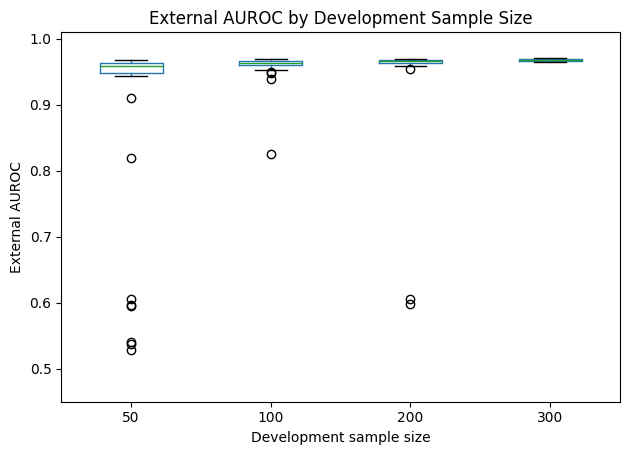

In [50]:
import matplotlib.pyplot as plt

plot_data = final_external_results[
    final_external_results["development_sample_size"] < 397
].copy()

plt.figure(figsize=(8, 5))

plot_data.boxplot(
    column="AUROC",
    by="development_sample_size",
    grid=False
)

plt.suptitle("")
plt.title("External AUROC by Development Sample Size")
plt.xlabel("Development sample size")
plt.ylabel("External AUROC")
plt.ylim(0.45, 1.01)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "GSE96058_FINAL_external_AUROC_by_sample_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 800x500 with 0 Axes>

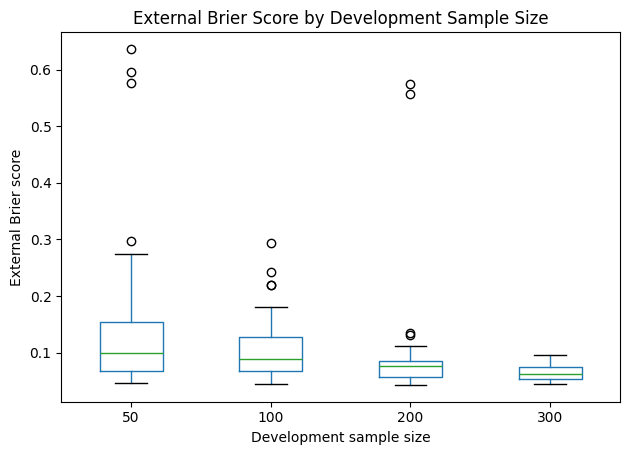

In [51]:
plt.figure(figsize=(8, 5))

plot_data.boxplot(
    column="brier_score",
    by="development_sample_size",
    grid=False
)

plt.suptitle("")
plt.title("External Brier Score by Development Sample Size")
plt.xlabel("Development sample size")
plt.ylabel("External Brier score")
plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "GSE96058_FINAL_external_Brier_score_by_sample_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()